In [14]:
import numpy as np

geno = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")
recon = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae/recon_all.npy")

# If geno is in {0,1,2}, scale to [0,1] to match recon:
geno_scaled = geno / 2.0

mse = np.mean((geno_scaled - recon)**2)
mae = np.mean(np.abs(geno_scaled - recon))

print("Per-entry MSE:", mse)
print("Per-entry MAE:", mae)


Per-entry MSE: 0.04994251
Per-entry MAE: 0.0845734


In [15]:
snp_means = geno_scaled.mean(axis=0, keepdims=True)
mse_baseline = np.mean((geno_scaled - snp_means)**2)
print("Baseline MSE:", mse_baseline)


Baseline MSE: 0.017931603


In [16]:
geno.shape

(1000, 10000)

In [12]:
# load the .trees sequence
import tskit
import numpy as np
ts = tskit.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/vae_sims/0/rep0/tree_sequence.trees")

In [13]:
G = ts.genotype_matrix()
G.shape

(677315, 2000)

In [14]:
biallelic = np.max(G, axis=1) <= 1

In [15]:
print(f'Number of non-biallelic variants: {G.shape[0] - biallelic.sum()}')

Number of non-biallelic variants: 1543


In [16]:
genotype_matrix = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/genotypes/all_individuals.npy")

In [17]:
genotype_matrix.shape

(1000, 10000)

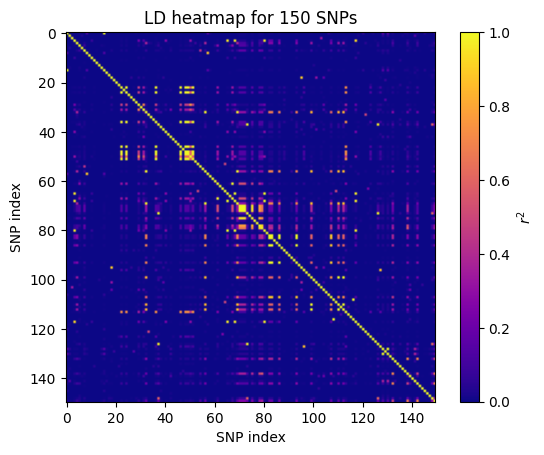

In [24]:
# Plot LD
import numpy as np

G = genotype_matrix.astype(np.float32)  # (1000, 10000), entries 0/1/2
n_snps = 150
start = (G.shape[1] - n_snps)//2
X = G[:, start:start+n_snps]

# mean-center and standardize each SNP
X = X - X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)
keep = (std[0] > 0)   # drop monomorphic
X = X[:, keep]
X = X / std[:, keep]

# correlation and r^2
R = (X.T @ X) / X.shape[0]
r2 = R * R
np.fill_diagonal(r2, 1.0)

r2.shape
import matplotlib.pyplot as plt
plt.imshow(r2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='$r^2$')
plt.title(F'LD heatmap for {n_snps} SNPs')
plt.xlabel('SNP index')
plt.ylabel('SNP index')
plt.show()


In [46]:
import numpy as np
import matplotlib.pyplot as plt

hap1 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap1.npy')
hap2 = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap2.npy')

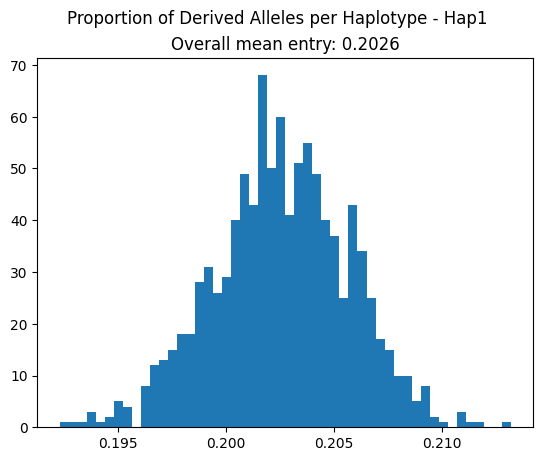

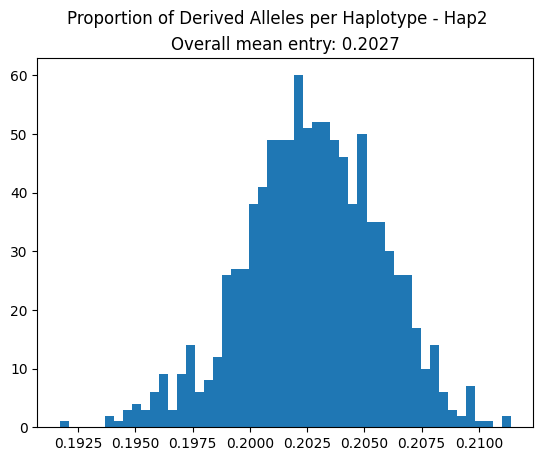

In [47]:
hap1_mean = hap1_f.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap1')
plt.title(f'Overall mean entry: {hap1_f.mean():.4f}')
plt.hist(hap1_mean, bins=50)
plt.show()

hap2_mean = hap2_f.mean(axis=1)
plt.figure()
plt.suptitle('Proportion of Derived Alleles per Haplotype - Hap2')
plt.title(f'Overall mean entry: {hap2_f.mean():.4f}')
plt.hist(hap2_mean, bins=50)
plt.show()


In [48]:
import pickle
with open('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/hap_meta.pkl', 'rb') as f:
    hap_meta = pickle.load(f)

In [49]:
hap_meta

,individual_id,population,hap_id,hap_index
0,0,YRI,0,0
1,1,YRI,0,1
2,2,YRI,0,2
3,3,YRI,0,3
4,4,YRI,0,4
...,...,...,...,...
1995,995,CEU,1,1995
1996,996,CEU,1,1996
1997,997,CEU,1,1997
1998,998,CEU,1,1998


Populations found: ['YRI' 'CEU']
Haplotype 1 - YRI: mean derived allele freq = 0.2021
Haplotype 1 - CEU: mean derived allele freq = 0.2030


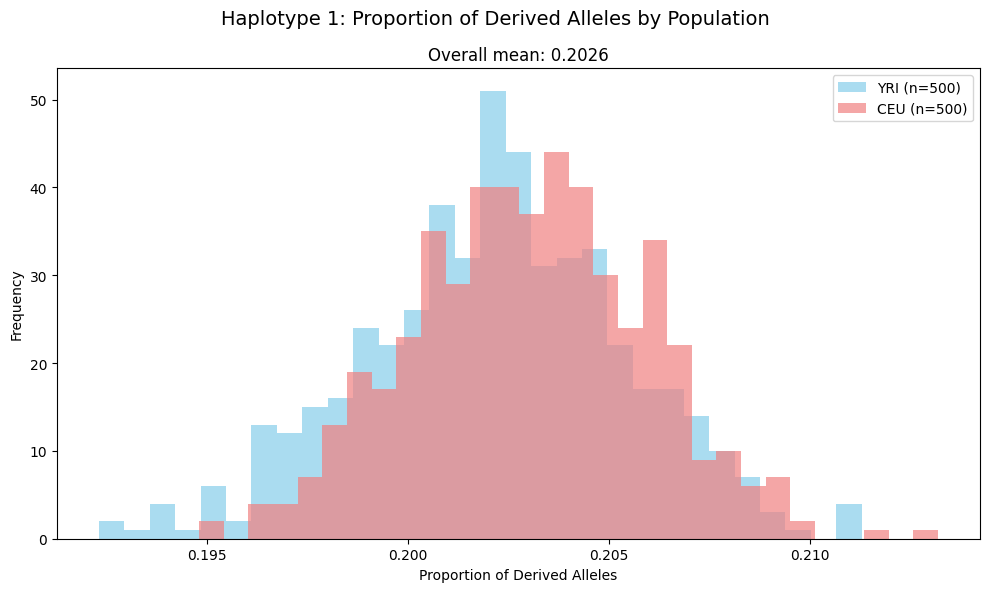

Haplotype 2 - YRI: mean derived allele freq = 0.2024
Haplotype 2 - CEU: mean derived allele freq = 0.2031


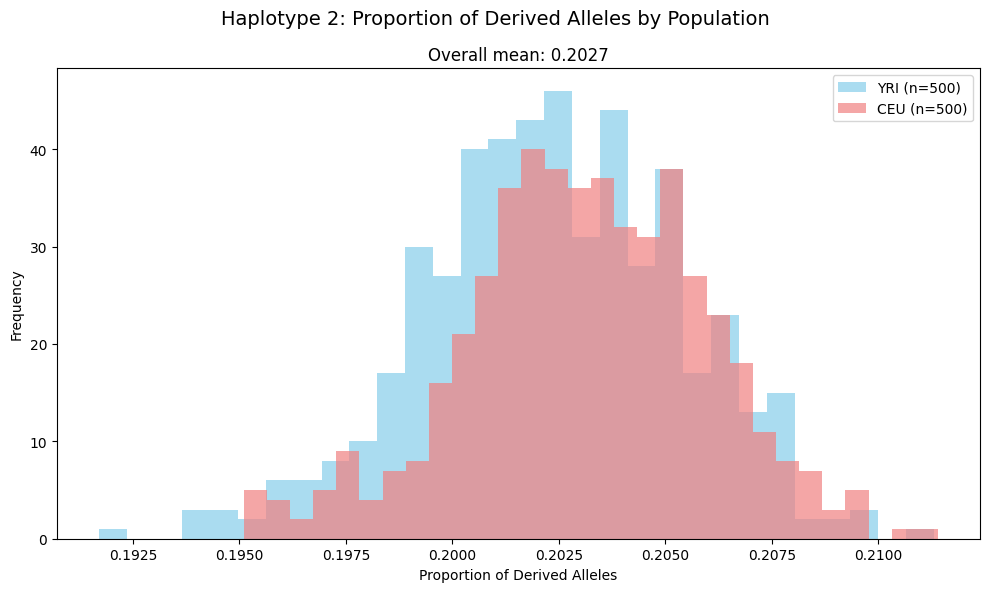


=== Summary ===
Population | Haplotype 1 Mean | Haplotype 2 Mean
--------------------------------------------------
YRI        |          0.2021 |          0.2024
CEU        |          0.2030 |          0.2031


In [50]:
# Get population labels for each individual (not haplotype yet)
import pandas as pd
meta = pd.read_pickle('/sietch_colab/akapoor/PRS_Portability/experiments/out_of_africa/processed_data/meta.pkl')

# Get unique populations
populations = meta['population'].unique()
print(f"Populations found: {populations}")

# Create masks for each population (individual level)
pop_masks = {}
for pop in populations:
    pop_masks[pop] = meta['population'] == pop

# Calculate mean derived allele frequency per haplotype for each individual
hap1_mean = hap1_f.mean(axis=1)
hap2_mean = hap2_f.mean(axis=1)

# Create plots for haplotype 1
plt.figure(figsize=(10, 6))
plt.suptitle('Haplotype 1: Proportion of Derived Alleles by Population', fontsize=14)

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
for i, pop in enumerate(populations):
    mask = pop_masks[pop]
    hap1_pop_mean = hap1_mean[mask]
    
    plt.hist(hap1_pop_mean, bins=30, alpha=0.7, label=f'{pop} (n={len(hap1_pop_mean)})', 
             color=colors[i % len(colors)])
    
    # Calculate and print mean for this population
    pop_mean = hap1_pop_mean.mean()
    print(f"Haplotype 1 - {pop}: mean derived allele freq = {pop_mean:.4f}")

plt.xlabel('Proportion of Derived Alleles')
plt.ylabel('Frequency')
plt.title(f'Overall mean: {hap1_f.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Create plots for haplotype 2
plt.figure(figsize=(10, 6))
plt.suptitle('Haplotype 2: Proportion of Derived Alleles by Population', fontsize=14)

for i, pop in enumerate(populations):
    mask = pop_masks[pop]
    hap2_pop_mean = hap2_mean[mask]
    
    plt.hist(hap2_pop_mean, bins=30, alpha=0.7, label=f'{pop} (n={len(hap2_pop_mean)})', 
             color=colors[i % len(colors)])
    
    # Calculate and print mean for this population
    pop_mean = hap2_pop_mean.mean()
    print(f"Haplotype 2 - {pop}: mean derived allele freq = {pop_mean:.4f}")

plt.xlabel('Proportion of Derived Alleles')
plt.ylabel('Frequency')
plt.title(f'Overall mean: {hap2_f.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Summary ===")
print("Population | Haplotype 1 Mean | Haplotype 2 Mean")
print("-" * 50)
for pop in populations:
    mask = pop_masks[pop]
    hap1_pop_mean = hap1_mean[mask].mean()
    hap2_pop_mean = hap2_mean[mask].mean()
    print(f"{pop:10s} | {hap1_pop_mean:15.4f} | {hap2_pop_mean:15.4f}")

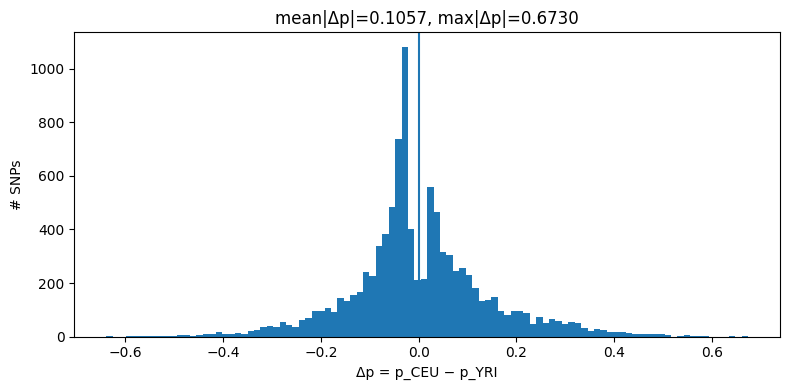

In [55]:
ceu = (meta["population"] == "CEU").to_numpy()
yri = (meta["population"] == "YRI").to_numpy()

# compute allele frequency per SNP within each pop (pool hap1+hap2)
p_ceu = np.concatenate([hap1[ceu], hap2[ceu]], axis=0).mean(axis=0)
p_yri = np.concatenate([hap1[yri], hap2[yri]], axis=0).mean(axis=0)

dp = p_ceu - p_yri
plt.figure(figsize=(8,4))
plt.hist(dp, bins=100)
plt.axvline(0)
plt.xlabel("Δp = p_CEU − p_YRI")
plt.ylabel("# SNPs")
plt.title(f"mean|Δp|={np.mean(np.abs(dp)):.4f}, max|Δp|={np.max(np.abs(dp)):.4f}")
plt.tight_layout(); plt.show()


Window 5376:5776 | kept 400 SNPs after window MAF≥0.01
Plotted lags: 200 / 200


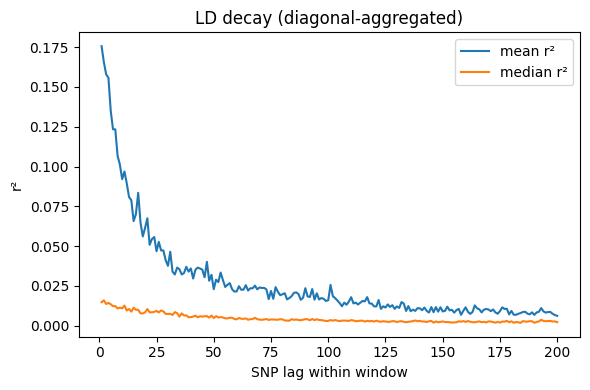

In [ ]:
Hbase = np.concatenate([hap1_f, hap2_f], axis=0)  # (2N, M)

window_len = 400
start = np.random.randint(0, Hbase.shape[1] - window_len)
H = Hbase[:, start:start + window_len].astype(float)

print(f"Window {start}:{start+window_len} | kept {H.shape[1]} SNPs after window MAF≥{maf_thresh_window}")

H -= H.mean(axis=0)
corr = np.corrcoef(H, rowvar=False)
corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
r2 = corr**2


# ---- LD decay by lag: use diagonal means/medians ----
M = r2.shape[0]
max_lag = min(200, M-1)
lags = np.arange(1, max_lag+1)

mean_r2 = np.array([np.mean(np.diag(r2, k=k)) for k in lags])
med_r2  = np.array([np.median(np.diag(r2, k=k)) for k in lags])
counts  = np.array([np.diag(r2, k=k).size for k in lags])

# only keep lags with enough pairs
min_pairs = 50
mask = counts >= min_pairs

print("Plotted lags:", mask.sum(), "/", mask.size)

plt.figure(figsize=(6,4))
plt.plot(lags[mask], mean_r2[mask], label="mean r²")
plt.plot(lags[mask], med_r2[mask],  label="median r²")
plt.xlabel("SNP lag within window")
plt.ylabel("r²")
plt.title("LD decay (diagonal-aggregated)")
plt.legend()
plt.tight_layout()
plt.show()


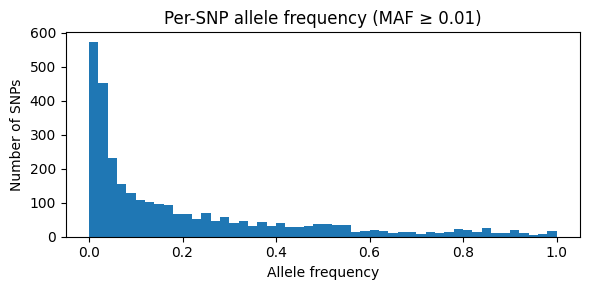

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# combine both haplotypes to get population allele frequency
Hbase = np.concatenate([hap1_f, hap2_f], axis=0)

plt.figure(figsize=(6,3))
plt.hist(p_filt, bins=50, range=(0,1))
plt.xlabel("Allele frequency")
plt.ylabel("Number of SNPs")
plt.title(f"Per-SNP allele frequency (MAF ≥ {maf_thresh})")
plt.tight_layout()
plt.show()



In [58]:
import numpy as np

def ld_pair_stats(H, j, k):
    x = H[:, j].astype(float)
    y = H[:, k].astype(float)
    pA, pB = x.mean(), y.mean()
    pAB = (x*y).mean()
    D = pAB - pA*pB
    denom = pA*(1-pA)*pB*(1-pB)
    if denom <= 0:
        return pA, pB, pAB, D, np.nan, np.nan
    r = D / np.sqrt(denom)
    return pA, pB, pAB, D, r, r*r

# choose two SNPs with decent MAF (global)
p = Hbase.mean(axis=0)
maf = np.minimum(p, 1-p)
good = np.where(maf >= 0.01)[0]   # try 0.01 if too strict

j, k = good[0], good[1]
print("Chosen SNPs:", j, k, "MAFs:", maf[j], maf[k])
print(ld_pair_stats(Hbase, j, k))


Hbase = np.concatenate([hap1_f, hap2_f], axis=0)  # after global poly/MAF filtering
p = Hbase.mean(axis=0)
maf = np.minimum(p, 1 - p)

good = np.where(maf >= 0.05)[0]   # try 0.01 if too strict
j, k = good[0], good[1]

pA, pB, pAB, D, r, r2 = ld_pair_stats(Hbase, j=j, k=k)
print("j,k:", j, k, "MAF:", maf[j], maf[k])
print(pA, pB, pAB, D, r2)


Chosen SNPs: 0 1 MAFs: 0.2375 0.044
(np.float64(0.2375), np.float64(0.044), np.float64(0.0), np.float64(-0.01045), np.float64(-0.11973173480249392), np.float64(0.014335688318814734))
j,k: 0 2 MAF: 0.2375 0.3635
0.2375 0.6365 0.2375 0.08633125 0.17788108637142158


In [59]:
x = Hbase[:, j].astype(int)
y = Hbase[:, k].astype(int)

code = 2*x + y  # 00->0, 01->1, 10->2, 11->3
freqs = np.bincount(code, minlength=4) / code.size
print("for SNPs j,k =", j, k, "freqs f00,f01,f10,f11 =", freqs)

for SNPs j,k = 0 2 freqs f00,f01,f10,f11 = [0.3635 0.399  0.     0.2375]
